# Product case 3: Selling Webinar Analysis
## Description of the tasks completed
- Provided with 2 main datasets (logs with time when users entered and left the webinar and with the source they came from) and 5 files with more detailed source information based on the platform. I analyzed sources and channels inside them, calculated conversions from registration to attendance.
- Utilized __matplotlib.pyplot__ library;
- Groupped by 5 minutes logs time and compared to the schedule of the webinar.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [3]:
df = pd.read_csv('logs.csv', sep=';')
clients = pd.read_csv('clients.csv', sep=';')

In [5]:
df.head()

,id_webinar,id_user,t_came,t_left
0,1341312,34217410,01.08.2022 12:25,01.08.22 13:00
1,1341312,34322153,01.08.2022 12:03,01.08.22 12:23
2,1341312,34386258,01.08.2022 12:43,01.08.22 13:14
3,1341312,34323708,01.08.2022 12:02,01.08.22 12:21
4,1341312,34316732,01.08.2022 12:02,01.08.22 12:24


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_webinar  1435 non-null   int64 
 1   id_user     1435 non-null   int64 
 2   t_came      1435 non-null   object
 3   t_left      1435 non-null   object
dtypes: int64(2), object(2)
memory usage: 45.0+ KB


In [9]:
df['t_came'] = pd.to_datetime(df['t_came'])
df['t_left'] = pd.to_datetime(df['t_left'])

C:\Users\Honor\AppData\Local\Temp\ipykernel_20180\2494829509.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t_left'] = pd.to_datetime(df['t_left'])


In [11]:
# Ensuring that the time was recorded correctly: t_came must not be later than t_left
print(df[df['t_came'] > df['t_left']]['id_webinar'].count(), 'users have wrong time recorded.')

43 users have wrong time recorded.


## 2 options are available:
1. Drop rows with __time delta < 0__ (lose 3% of data)
2. Swap values in __t_came__ and __t_left__

I will not delete rows, swapping values in columns instead

In [13]:
incorrect_data = df['t_came'] > df['t_left']

In [15]:
df.loc[incorrect_data, ['t_came', 't_left']] = df.loc[incorrect_data, ['t_left', 't_came']].values

In [17]:
df['session_duration'] = df['t_left'] - df['t_came']

In [19]:
df.describe()

,id_webinar,id_user,t_came,t_left,session_duration
count,1435.0,1.435000e+03,1435,1435,1435
mean,1341312.0,3.432994e+07,2022-01-08 12:26:10.160278784,2022-01-08 12:54:41.310104576,0 days 00:28:31.149825783
min,1341312.0,3.421451e+07,2022-01-08 12:00:00,2022-01-08 12:00:00,0 days 00:00:00
25%,1341312.0,3.428006e+07,2022-01-08 12:06:00,2022-01-08 12:23:00,0 days 00:08:00
50%,1341312.0,3.433094e+07,2022-01-08 12:18:00,2022-01-08 12:57:00,0 days 00:22:00
75%,1341312.0,3.438282e+07,2022-01-08 12:40:00,2022-01-08 13:23:00,0 days 00:45:00
max,1341312.0,3.443212e+07,2022-01-08 13:48:00,2022-01-08 13:59:00,0 days 01:46:00
std,0.0,6.279863e+04,NaN,NaN,0 days 00:24:15.568062335


In [21]:
# converting to minutes
df['minutes_spent'] = df.session_duration.dt.total_seconds() / 60.0

In [23]:
df.head()

,id_webinar,id_user,t_came,t_left,session_duration,minutes_spent
0,1341312,34217410,2022-01-08 12:25:00,2022-01-08 13:00:00,0 days 00:35:00,35.0
1,1341312,34322153,2022-01-08 12:03:00,2022-01-08 12:23:00,0 days 00:20:00,20.0
2,1341312,34386258,2022-01-08 12:43:00,2022-01-08 13:14:00,0 days 00:31:00,31.0
3,1341312,34323708,2022-01-08 12:02:00,2022-01-08 12:21:00,0 days 00:19:00,19.0
4,1341312,34316732,2022-01-08 12:02:00,2022-01-08 12:24:00,0 days 00:22:00,22.0


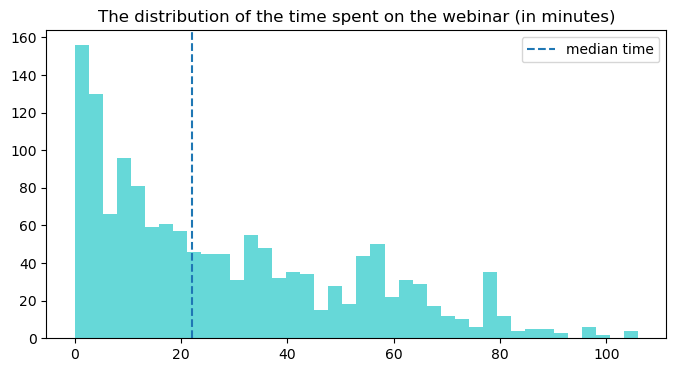

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(df['minutes_spent'], bins=40, alpha=0.6, color = 'c')
plt.axvline(df['minutes_spent'].median(), label='median time', linestyle='--')
plt.title('The distribution of the time spent on the webinar (in minutes)')
plt.legend()
plt.show()

## Analyzing channels explicitly
### Task 1: studying the conversion rate of webinar attendance from webinar registrations from various platforms, identifying a platform that is inflating registrations.

In [27]:
clients.head()

,id_user,source
0,34214513,?utm_source=telegram%adv=public1W%WSJ%3543%A
1,34432122,?utm_source=instagram%placement=blogger4I%FPY%...
2,34332094,?utm_source=telegram%adv=public1W%VRI%6516%J
3,34273819,?utm_source=telegram%adv=public3M%HSJ%6142%K
4,34385079,?utm_source=facebook%fbadv=source2R%TIY%8021%C


In [29]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id_user  1257 non-null   int64 
 1   source   1257 non-null   object
dtypes: int64(1), object(1)
memory usage: 19.8+ KB


In [31]:
# Extracting useful infro from source column: the channel
def get_info(data, source):
    data['source'] = data[source].str.split('=', expand=True, n=1)[1].str.split('%', expand=True, n=1)[0]
    return data

In [33]:
clients = get_info(data = clients, source = 'source')

In [35]:
clients.tail()

,id_user,source
1252,34359444,telegram
1253,34281608,vkontakte
1254,34428279,instagram
1255,34358410,email
1256,34383850,email


In [37]:
# Performing a join on clients and log tables to calculate the share of users from different platforms
df = pd.merge(df, clients, how='inner', on='id_user')

In [39]:
print("Number of unique users:", df['id_user'].nunique())
print("Number of logs:", df['id_user'].count())

Number of unique users: 1257
Number of logs: 1435


In [41]:
df = df.drop(columns=['id_webinar', 'session_duration'])

In [43]:
sources = df.groupby('source')['id_user'].nunique().reset_index()

In [45]:
sources['share'] = sources['id_user']/ sources['id_user'].sum() * 100

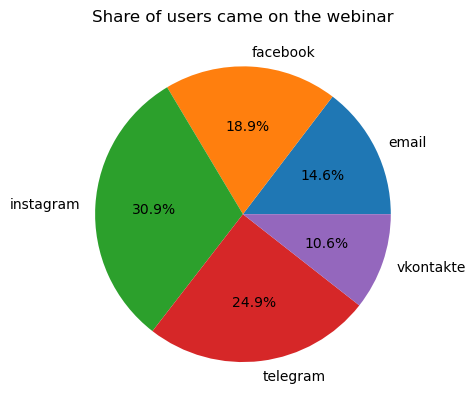

In [47]:
plt.pie(x=sources['share'], labels=sources['source'], autopct = '%1.1f%%')
plt.title('Share of users came on the webinar')
plt.show()

### Dataframes with registration info from sources

In [49]:
telegram = pd.read_csv('tg_reg.csv', sep=';')
vkontakte = pd.read_csv('vk_reg.csv', sep=';')
email = pd.read_csv('email_reg.csv', sep=';')
facebook = pd.read_csv('fb_reg.csv', sep=';')
instagram = pd.read_csv('inst_reg.csv', sep=';')

In [51]:
source = [telegram, vkontakte, email, instagram, facebook]
source_name = ['telegram', 'vkontakte', 'email', 'instagram', 'facebook']

id_reg_cnt = []
time_reg_cnt = []
for s in source:
    time_reg_cnt.append(s['time_reg'].count())
    id_reg_cnt.append(s['id_reg'].count())

In [53]:
for i in range(len(source_name)):
    print('Source:', source_name[i])
    print('Number of timestamps with registration:', time_reg_cnt[i])
    print('Number of id registrations:', id_reg_cnt[i])

Source: telegram
Number of timestamps with registration: 3210
Number of id registrations: 3079
Source: vkontakte
Number of timestamps with registration: 1731
Number of id registrations: 1731
Source: email
Number of timestamps with registration: 3128
Number of id registrations: 3128
Source: instagram
Number of timestamps with registration: 5255
Number of id registrations: 5255
Source: facebook
Number of timestamps with registration: 2663
Number of id registrations: 2663


Somewhy the number of id_reg doesn't match timestamps, will consider the number of time_reg as the number of registrations

In [55]:
telegram[telegram['id_reg'].isna()].groupby('public_label')['time_reg'].count().reset_index()

,public_label,time_reg
0,public4,131


It seems that only source __public4__ from Telegram channel has 131 unreal registrations 

In [57]:
data = {'source' : source_name, 'reg_cnt' : time_reg_cnt}

In [59]:
cnt_reg = pd.DataFrame.from_dict(data=data)

## Joining with number of participants on the webinar (sources table)

In [61]:
sources = pd.merge(cnt_reg, sources, how='inner', on='source')

In [63]:
sources

,source,reg_cnt,id_user,share
0,telegram,3210,313,24.900557
1,vkontakte,1731,133,10.580748
2,email,3128,184,14.638027
3,instagram,5255,389,30.946698
4,facebook,2663,238,18.933970


In [65]:
sources['register_to_attendance'] = sources['id_user'] / sources['reg_cnt'] * 100
sources['register_share'] = sources['reg_cnt']/ sources['reg_cnt'].sum() * 100
sources = sources.rename(columns={'share' : 'attendance_share', 'id_user' : 'attended_cnt'})

In [67]:
sources = sources.sort_values(by='attended_cnt', ascending=False)

In [69]:
sources

,source,reg_cnt,attended_cnt,attendance_share,register_to_attendance,register_share
3,instagram,5255,389,30.946698,7.402474,32.870457
0,telegram,3210,313,24.900557,9.750779,20.078814
4,facebook,2663,238,18.933970,8.937289,16.657284
2,email,3128,184,14.638027,5.882353,19.565897
1,vkontakte,1731,133,10.580748,7.683420,10.827547


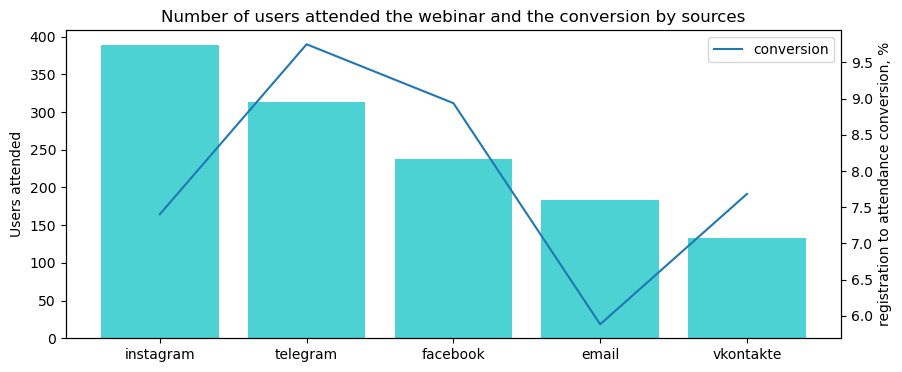

In [71]:
fig, ax1 = plt.subplots(figsize=(10,4))
ax1.bar(sources['source'], sources['attended_cnt'], color = 'c', alpha=0.7, label='users count')
ax1.set_ylabel('Users attended')

ax2 = ax1.twinx()
ax2.plot(sources['source'], sources['register_to_attendance'], label = 'conversion')
ax2.set_ylabel('registration to attendance conversion, %')

plt.title('Number of users attended the webinar and the conversion by sources')
plt.legend()
plt.show()

### The largest conversion is from Telegram. However, we need to explore each source inside

In [73]:
print(telegram.columns)

Index(['id_reg', 'public_label', 'time_reg'], dtype='object')


In [75]:
tg_public = telegram.groupby('public_label')['time_reg'].count().reset_index()
tg_public = tg_public.sort_values(by='time_reg', ascending=False)

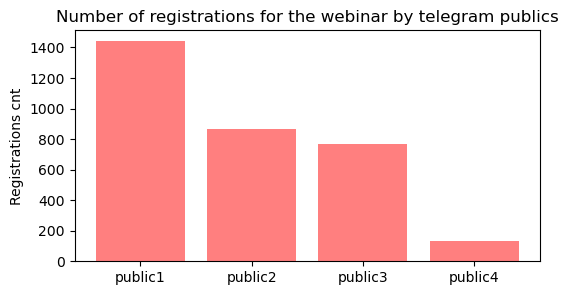

In [77]:
plt.figure(figsize=(6,3))
plt.bar(tg_public['public_label'], tg_public['time_reg'], color='r', alpha=0.5)
plt.title('Number of registrations for the webinar by telegram publics')
plt.ylabel('Registrations cnt')
plt.show()

In [79]:
print(vkontakte.columns)

Index(['id_reg', 'group_label', 'time_reg'], dtype='object')


In [81]:
vk_group = vkontakte.groupby('group_label')['time_reg'].count().reset_index()
vk_group = vk_group.sort_values(by='time_reg', ascending=False)

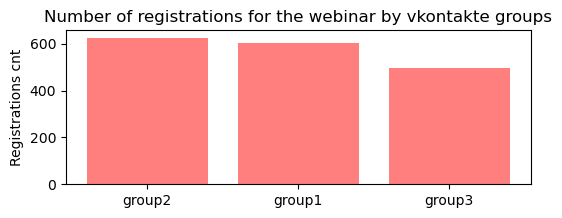

In [83]:
plt.figure(figsize=(6,2))
plt.bar(vk_group['group_label'], vk_group['time_reg'], color='r', alpha=0.5)
plt.title('Number of registrations for the webinar by vkontakte groups')
plt.ylabel('Registrations cnt')
plt.show()

Almost uniformly distributed number

In [85]:
print(email.columns)

Index(['id_reg', 'domain_label', 'time_reg'], dtype='object')


In [87]:
email_domain = email.groupby('domain_label')['time_reg'].count().reset_index()
email_domain = email_domain.sort_values(by='time_reg', ascending=False)

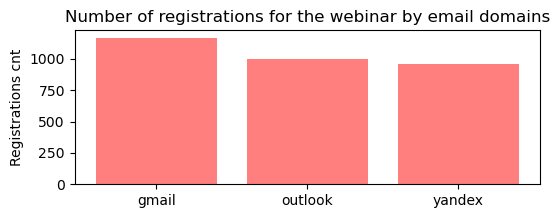

In [89]:
plt.figure(figsize=(6,2))
plt.bar(email_domain['domain_label'], email_domain['time_reg'], color='r', alpha=0.5)
plt.title('Number of registrations for the webinar by email domains')
plt.ylabel('Registrations cnt')
plt.show()

Similar to vkontakte situation

In [91]:
print(instagram.columns)

Index(['id_reg', 'blogger_label', 'time_reg'], dtype='object')


In [93]:
inst_blogger = instagram.groupby('blogger_label')['time_reg'].count().reset_index()
inst_blogger = inst_blogger.sort_values(by='time_reg', ascending=False)

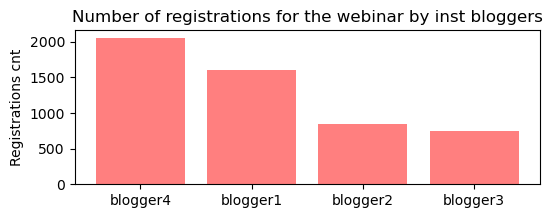

In [95]:
plt.figure(figsize=(6,2))
plt.bar(inst_blogger['blogger_label'], inst_blogger['time_reg'], color='r', alpha=0.5)
plt.title('Number of registrations for the webinar by inst bloggers')
plt.ylabel('Registrations cnt')
plt.show()

In [97]:
print(facebook.columns)

Index(['id_reg', 'source_label', 'time_reg'], dtype='object')


In [99]:
fb_source = facebook.groupby('source_label')['time_reg'].count().reset_index()
fb_source = fb_source.sort_values(by='time_reg', ascending=False)

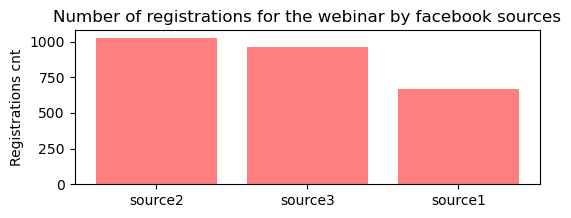

In [101]:
plt.figure(figsize=(6,2))
plt.bar(fb_source['source_label'], fb_source['time_reg'], color='r', alpha=0.5)
plt.title('Number of registrations for the webinar by facebook sources')
plt.ylabel('Registrations cnt')
plt.show()

## Studying webinar attendance in terms of influx and churn.
### Task 2.1: Comparing churn with the webinar schedule and highlighting the portion of the webinar that needs improvement.

In [277]:
df.head()

,id_user,t_came,t_left,minutes_spent,source
0,34217410,2022-01-08 12:25:00,2022-01-08 13:00:00,35.0,telegram
1,34322153,2022-01-08 12:03:00,2022-01-08 12:23:00,20.0,telegram
2,34386258,2022-01-08 12:43:00,2022-01-08 13:14:00,31.0,instagram
3,34323708,2022-01-08 12:02:00,2022-01-08 12:21:00,19.0,instagram
4,34316732,2022-01-08 12:02:00,2022-01-08 12:24:00,22.0,telegram


In [296]:
# Storing unique timestamps of time came and left
t_came = df['t_came'].unique().tolist()
t_left = df['t_left'].unique().tolist()

In [298]:
timestamps = t_came + t_left

In [300]:
timestamps = set(timestamps) # keeping only unique values
timestamps = list(timestamps) # converting to the list
timestamps.sort()

In [302]:
timestamps[:5]

[Timestamp('2022-01-08 12:00:00'),
 Timestamp('2022-01-08 12:01:00'),
 Timestamp('2022-01-08 12:02:00'),
 Timestamp('2022-01-08 12:03:00'),
 Timestamp('2022-01-08 12:04:00')]

In [304]:
users_online = []

for i in range(len(timestamps)):
    minute = timestamps[i]
    users_online.append(((df['t_came'] <= minute) & (df['t_left'] > minute)).sum())

In [306]:
viewers_by_minutes = pd.DataFrame({'time' : timestamps, 'viewers_cnt' : users_online})
viewers_by_minutes['time'] = pd.to_datetime(viewers_by_minutes['time'])

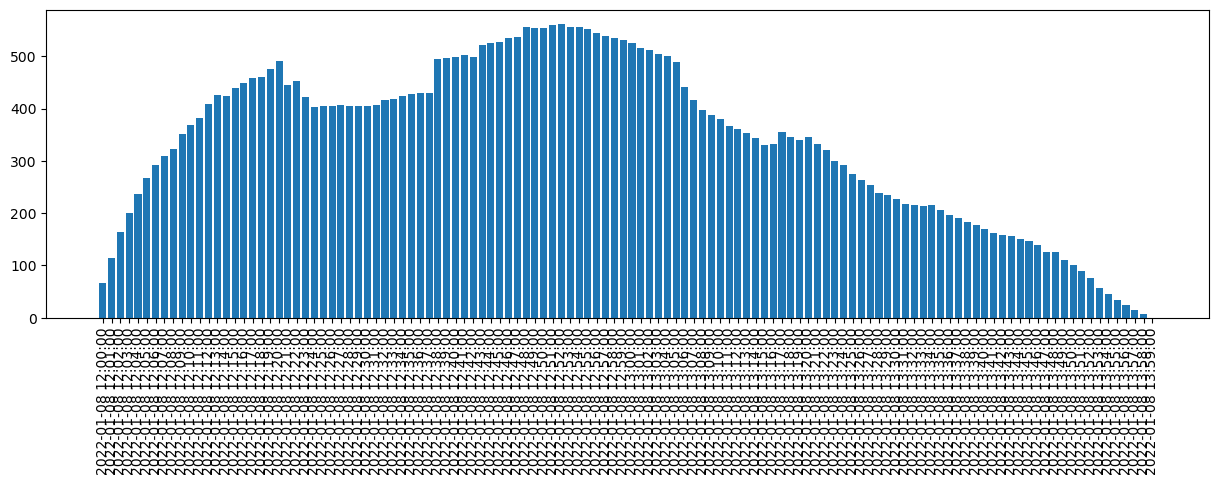

In [308]:
plt.figure(figsize=(15,4))
plt.bar(viewers_by_minutes['time'].astype(str), viewers_by_minutes['viewers_cnt'])
plt.xticks(rotation=90)
plt.show()

### Too hard to see insights from such barchart. Groupping by 5 minutes instead

In [310]:
viewers_by_minutes.head()

,time,viewers_cnt
0,2022-01-08 12:00:00,67
1,2022-01-08 12:01:00,115
2,2022-01-08 12:02:00,163
3,2022-01-08 12:03:00,200
4,2022-01-08 12:04:00,236


In [312]:
# rounding by 5 minutes
viewers_by_minutes['time_5min'] = viewers_by_minutes['time'].dt.floor('5min')

# groupping and taking average value
grouped = viewers_by_minutes.groupby('time_5min')['viewers_cnt'].mean().reset_index()

In [314]:
grouped['viewers_cnt'] = round(grouped['viewers_cnt'])

In [316]:
grouped.head()

,time_5min,viewers_cnt
0,2022-01-08 12:00:00,156.0
1,2022-01-08 12:05:00,308.0
2,2022-01-08 12:10:00,402.0
3,2022-01-08 12:15:00,456.0
4,2022-01-08 12:20:00,442.0


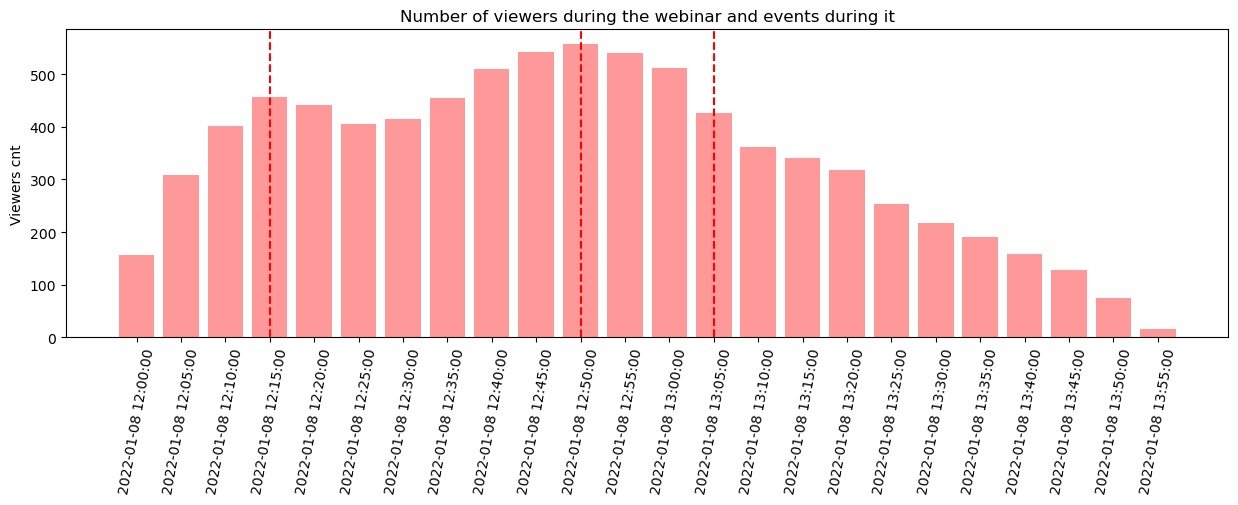

In [336]:
# Highlight the time according to the schedule
marks = ['2022-01-08 12:15', '2022-01-08 12:50', '2022-01-08 13:05']

marks = pd.to_datetime(marks)

plt.figure(figsize=(15,4))
plt.bar(grouped['time_5min'].astype(str), grouped['viewers_cnt'], color = 'r', alpha=0.4)
plt.xticks(rotation=80)

for t in marks:
    plt.axvline(x=str(t.floor('5min')), linestyle='--', color = 'r')

plt.title('Number of viewers during the webinar and events during it')
plt.ylabel('Viewers cnt')
    
plt.show()

### Webinar Schedule:

1. 1st sales session: 12:00 PM
2. Theoretical analytics session: 12:15 PM
3. 2nd sales session: 12:50 PM
4. Practical analytics session: 1:05 PM
5. Ending: 2:00 PM

### Task 2.2: Exploring whether the length of time a client stays on a webinar depends on the source they came from?

In [354]:
duration_by_source = df.groupby('source')['minutes_spent'].mean().reset_index()
duration_by_source['minutes_spent'] = round(duration_by_source['minutes_spent'],2)

In [356]:
duration_by_source

,source,minutes_spent
0,email,28.61
1,facebook,27.27
2,instagram,28.99
3,telegram,28.43
4,vkontakte,29.68


On average minutes spent on the webinar is almost the same for different sources